In [1]:
import os

# Directory containing all CDF files
cdf_directory = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//"

# Function to list and sort CDF files in a directory
def list_cdf_files(directory):
    cdf_files = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith('.cdf')]
    cdf_files.sort()  # Sort files if necessary (e.g., by date)
    return cdf_files

# List all CDF files
cdf_files = list_cdf_files(cdf_directory)
print("CDF files to process:", cdf_files)


CDF files to process: ['C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//mms1_fpi_brst_l2_des-dist_20240301230743_v3.4.0.cdf', 'C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//mms1_fpi_brst_l2_des-dist_20240301230953_v3.4.0.cdf', 'C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//mms1_fpi_brst_l2_des-dist_20240301232023_v3.4.0.cdf', 'C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//mms1_fpi_brst_l2_des-dist_20240301232233_v3.4.0.cdf', 'C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//mms1_fpi_brst_l2_des-dist_20240301232443_v3.4.0.cdf', 'C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//mms1_fpi_brst_l2_des-di

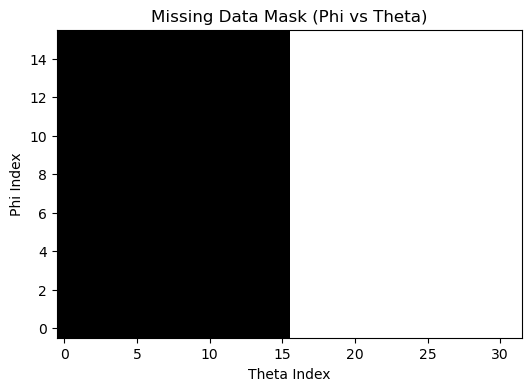

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define dimensions based on your data shape
energy_levels = 32  # Adjust if different
phi_bins = 16
theta_bins = 32

# Create a 2D mask for phi_bins x theta_bins
# Mask the right half: theta_bins >= theta_bins // 2
mask_2d = np.zeros((phi_bins, theta_bins), dtype=bool)
mask_2d[:, theta_bins//2:] = True  # Masking the right half

# Visualize the mask for one energy level (optional)
plt.figure(figsize=(6, 4))
plt.imshow(mask_2d, aspect='auto', origin='lower', cmap='gray')
plt.title('Missing Data Mask (Phi vs Theta)')
plt.xlabel('Theta Index')
plt.ylabel('Phi Index')
plt.show()


In [5]:
import cdflib
import numpy as np
import matplotlib.pyplot as plt

# Define dimensions based on your data shape
phi_bins = 16
theta_bins = 32
energy_levels = 32  # Adjust if necessary

# Create the mask for the right half of the theta dimension
mask_2d = np.zeros((phi_bins, theta_bins), dtype=bool)
mask_2d[:, theta_bins // 2:] = True

# Load and preprocess data from a single CDF file
def load_and_preprocess_cdf(filepath, var_name):
    """
    Load data from a CDF file and reshape for model input.
    
    Parameters:
    - filepath (str): Path to the CDF file.
    - var_name (str): Variable name to extract from the CDF file.
    
    Returns:
    - X (numpy.ndarray): Preprocessed data ready for model training.
    """
    with cdflib.CDF(filepath) as cdf_file:
        data = cdf_file.varget(var_name)  # Expected shape: (time_steps, energy_levels, phi_bins, theta_bins)
    
    # Transpose to (time_steps, phi_bins, theta_bins, energy_levels) and reshape for model
    data = data.transpose(0, 3, 2, 1)
    X = data.reshape(-1, phi_bins, theta_bins, energy_levels, 1).astype('float32')
    return X

# Use the first file from the list for testing
cdf_directory = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//"
sample_file = os.path.join(cdf_directory, os.listdir(cdf_directory)[0])

# Load the data
X_data = load_and_preprocess_cdf(sample_file, 'mms1_des_dist_brst')
print(f"Loaded data shape: {X_data.shape}")

# Sequentially split into training, validation, and test sets
n_train = 1000  # Adjust based on data size
k_val = 200
k_test = 200

if n_train + k_val + k_test > X_data.shape[0]:
    raise ValueError("Not enough data in the file for specified split sizes.")

X_train = X_data[:n_train]
X_val = X_data[n_train:n_train + k_val]
X_test = X_data[n_train + k_val:n_train + k_val + k_test]

print(f"Training samples: {X_train.shape[0]}, Validation samples: {X_val.shape[0]}, Test samples: {X_test.shape[0]}")

# Apply mask to the validation set only
X_val_masked = X_val.copy()
mask_expanded = np.expand_dims(mask_2d, axis=(0, 3, 4))  # Shape: (1, phi_bins, theta_bins, 1, 1)
mask_broadcast = np.tile(mask_expanded, (X_val_masked.shape[0], 1, 1, energy_levels, 1))  # Shape: (samples, phi_bins, theta_bins, energy_levels, 1)

# Set masked regions to 0.0
X_val_masked[mask_broadcast] = 0.0
print("Mask applied to validation set.")


Loaded data shape: (4333, 16, 32, 32, 1)
Training samples: 1000, Validation samples: 200, Test samples: 200
Mask applied to validation set.


In [19]:
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, UpSampling3D
from tensorflow.keras.models import Model

def build_autoencoder(input_shape):
    """
    Build and compile the autoencoder model.
    
    Parameters:
    - input_shape (tuple): Shape of the input data (phi_bins, theta_bins, energy_levels, channels).
    
    Returns:
    - autoencoder (Model): Compiled Keras model.
    """
    # Encoder
    input_img = Input(shape=input_shape)
    x = Conv3D(32, (3, 3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling3D((2, 2, 2), padding='same')(x)
    x = Conv3D(64, (3, 3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling3D((2, 2, 2), padding='same')(x)
    
    # Decoder
    x = Conv3D(64, (3, 3, 3), activation='relu', padding='same')(encoded)
    x = UpSampling3D((2, 2, 2))(x)
    x = Conv3D(32, (3, 3, 3), activation='relu', padding='same')(x)
    x = UpSampling3D((2, 2, 2))(x)
    decoded = Conv3D(1, (3, 3, 3), activation='sigmoid', padding='same')(x)
    
    # Autoencoder model
    autoencoder = Model(inputs=input_img, outputs=decoded)
    return autoencoder

# Define input shape based on data dimensions
input_shape = (phi_bins, theta_bins, energy_levels, 1)  # Adjusted to match your data

# Build the autoencoder
autoencoder = build_autoencoder(input_shape)
autoencoder.summary()


Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 16, 32, 32, 1)]   0         
                                                                 
 conv3d_5 (Conv3D)           (None, 16, 32, 32, 32)    896       
                                                                 
 max_pooling3d_2 (MaxPoolin  (None, 8, 16, 16, 32)     0         
 g3D)                                                            
                                                                 
 conv3d_6 (Conv3D)           (None, 8, 16, 16, 64)     55360     
                                                                 
 max_pooling3d_3 (MaxPoolin  (None, 4, 8, 8, 64)       0         
 g3D)                                                            
                                                                 
 conv3d_7 (Conv3D)           (None, 4, 8, 8, 64)       1106

In [14]:
# Ensure that X_data is reshaped to (time_steps, energy_levels, phi_bins, theta_bins)
# Start from X_data in shape (time_steps, phi_bins, theta_bins, energy_levels, 1)
# Reshape to (time_steps, energy_levels, phi_bins, theta_bins)
f = X_data.reshape(-1, 32, 16, 32).transpose(0, 1, 2, 3)  # Shape: (time_steps, energy_levels, phi_bins, theta_bins)

# Initialize Skymap and calculate moments
steps = f.shape[0]
skymap = Skymap(steps, "MMS1_skymaps", nen=f.shape[1])  # Set 'nen' to match the energy levels dimension
skymap.skymap = f
moments = skymap.momsTS  # Calculate moments

# Extract density moment
actual_density = moments.density  # This gives the density over time
print("Calculated actual density shape:", actual_density.shape)


Calculated actual density shape: (4333,)


In [15]:
import tensorflow as tf
from tensorflow.keras import backend as K

# Convert actual_density to a tensor for use in the custom loss function
actual_density_tensor = tf.convert_to_tensor(actual_density, dtype=tf.float32)


In [16]:
def calculate_density(cube):
    """
    Calculate the 'density' moment of the cube by summing over spatial dimensions.
    
    Parameters:
    - cube (Tensor): 5D tensor with shape (batch, phi_bins, theta_bins, energy_levels, channels).
    
    Returns:
    - density: Summed 'density' moment.
    """
    return K.sum(cube, axis=(1, 2, 3))  # Sum over phi, theta, and energy dimensions

def density_loss(y_true, y_pred):
    """
    Custom loss function based on the difference in densities between actual and predicted cubes.
    Parameters:
    - y_true (Tensor): Actual cube.
    - y_pred (Tensor): Predicted cube.
    """
    predicted_density = calculate_density(y_pred)
    return K.mean(K.square(actual_density_tensor - predicted_density))  # Mean squared difference of densities


In [20]:
def combined_loss(y_true, y_pred):
    """
    Custom loss that combines MSE and density-based loss.
    Calculates the mean of MSE and density loss.
    """
    # Calculate MSE
    mse = tf.keras.losses.mean_squared_error(y_true, y_pred)
    
    # Calculate density loss
    density = density_loss(y_true, y_pred)
    
    # Return the mean of MSE and density loss
    return K.mean(mse + density) / 2.0


In [21]:
from tensorflow.keras.callbacks import EarlyStopping

# Compile the autoencoder with the combined loss
autoencoder.compile(optimizer='adam', loss=combined_loss)

# Set up early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss for stopping
    patience=10,         # Number of epochs with no improvement after which to stop
    restore_best_weights=True  # Restore the best weights after stopping
)

# Increase the number of epochs and train with early stopping
epochs = 1000  # Increased epochs
batch_size = 32

history = autoencoder.fit(
    X_train, X_train,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=False,  # Maintain sequential order
    validation_data=(X_val_masked, X_val),
    callbacks=[early_stopping]  # Apply early stopping
)


Epoch 1/1000
32/32 [==============================] - 16s 457ms/step - loss: 6660188.0000 - val_loss: 215.8956
Epoch 2/1000
32/32 [==============================] - 14s 440ms/step - loss: 196.8622 - val_loss: 18.9551
Epoch 3/1000
32/32 [==============================] - 14s 434ms/step - loss: 25.8142 - val_loss: 3.6467
Epoch 4/1000
32/32 [==============================] - 14s 441ms/step - loss: 4.3506 - val_loss: 3.5296
Epoch 5/1000
32/32 [==============================] - 14s 445ms/step - loss: 3.5549 - val_loss: 3.5323
Epoch 6/1000
32/32 [==============================] - 14s 447ms/step - loss: 3.5263 - val_loss: 3.5252
Epoch 7/1000
32/32 [==============================] - 14s 433ms/step - loss: 3.5251 - val_loss: 3.5251
Epoch 8/1000
32/32 [==============================] - 14s 433ms/step - loss: 3.5251 - val_loss: 3.5251
Epoch 9/1000
32/32 [==============================] - 14s 437ms/step - loss: 3.5251 - val_loss: 3.5251
Epoch 10/1000
32/32 [==============================] - 14s 43

In [22]:
from sklearn.metrics import mean_squared_error, r2_score

# Predict on the test set
X_test_pred = autoencoder.predict(X_test)

# Calculate metrics on masked regions (if applicable)
masked_regions = X_val_masked == 0.0  # Boolean mask for masked regions

# Flatten masked regions for actual and predicted data
actual_masked = X_test[masked_regions].flatten()
predicted_masked = X_test_pred[masked_regions].flatten()

# Calculate MSE and R² for masked regions
mse_masked = mean_squared_error(actual_masked, predicted_masked)
r2_masked = r2_score(actual_masked, predicted_masked)

print(f"Mean Squared Error on masked regions: {mse_masked}")
print(f"R² Score on masked regions: {r2_masked}")


7/7 [==============================] - 1s 71ms/step
Mean Squared Error on masked regions: 0.00010499320342205465
R² Score on masked regions: 0.0


In [24]:
# Calculate predictions on the test set
X_test_pred = autoencoder.predict(X_test)

# Calculate MSE for the test set
mse_test = tf.keras.losses.mean_squared_error(X_test.flatten(), X_test_pred.flatten())
mse_test = tf.reduce_mean(mse_test).numpy()  # Mean over all test samples

# Calculate density loss for the test set
def calculate_density(cube):
    """Calculate the 'density' moment by summing over spatial dimensions."""
    return tf.reduce_sum(cube, axis=(1, 2, 3))  # Sum over phi, theta, and energy dimensions

def density_loss_on_test(y_true, y_pred):
    """Calculate density-based loss for the test set."""
    actual_density = calculate_density(y_true)
    predicted_density = calculate_density(y_pred)
    return tf.reduce_mean(tf.square(actual_density - predicted_density))

# Compute density loss on the test set
density_test = density_loss_on_test(X_test, X_test_pred).numpy()

# Calculate combined test loss as the mean of MSE and density loss
combined_test_loss = (mse_test + density_test) / 2.0

print(f"Test MSE: {mse_test}")
print(f"Test Density Loss: {density_test}")
print(f"Combined Test Loss: {combined_test_loss}")


7/7 [==============================] - 0s 66ms/step
Test MSE: 0.00011777182953665033
Test Density Loss: 430.7598571777344
Combined Test Loss: 215.37998962402344


In [18]:
# Train the model
history = autoencoder.fit(
    X_train, X_train,  # Use X_train for both input and output as it's an autoencoder
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_data=(X_val_masked, X_val)  # Masked validation input with original validation output
)

Epoch 1/50
32/32 [==============================] - 19s 524ms/step - loss: 1.4612e-10 - density_loss: 437.6640 - val_loss: 1.2896e-10 - val_density_loss: 437.6731
Epoch 2/50
32/32 [==============================] - 17s 516ms/step - loss: 1.1288e-10 - density_loss: 437.6828 - val_loss: 9.6316e-11 - val_density_loss: 437.6928
Epoch 3/50
32/32 [==============================] - 17s 517ms/step - loss: 8.4349e-11 - density_loss: 437.7010 - val_loss: 7.2599e-11 - val_density_loss: 437.7092
Epoch 4/50
32/32 [==============================] - 17s 519ms/step - loss: 6.4420e-11 - density_loss: 437.7155 - val_loss: 5.6397e-11 - val_density_loss: 437.7219
Epoch 5/50
32/32 [==============================] - 16s 513ms/step - loss: 5.0746e-11 - density_loss: 437.7268 - val_loss: 4.5148e-11 - val_density_loss: 437.7317
Epoch 6/50
32/32 [==============================] - 16s 505ms/step - loss: 4.1122e-11 - density_loss: 437.7356 - val_loss: 3.7087e-11 - val_density_loss: 437.7395
Epoch 7/50
32/32 [====

In [ ]:
history = autoencoder.fit(
    X_train, X_train,  # Use X_train for both input and output as it's an autoencoder
    epochs=epochs,
    batch_size=batch_size,
    shuffle=False,
    validation_data=(X_val_masked, X_val)  # Masked validation input with original validation output
)

In [ ]:
# Re-initialize model weights
for layer in autoencoder.layers:
    if hasattr(layer, 'kernel_initializer'):
        layer.kernel.initializer.run(session=tf.compat.v1.keras.backend.get_session())

# Then re-run the fit
history = autoencoder.fit(
    X_train, X_train,
    epochs=epochs,
    batch_size=32,
    shuffle=False,
    validation_data=(X_val_masked, X_val)
)
